# Exploratory Data Analysis: Mathematics Genealogy Project

This notebook explores the MGP dataset of 338,526 mathematician records scraped from
the [Mathematics Genealogy Project](https://www.mathgenealogy.org/). The goal is to
understand the structure, coverage, and historical trends in the data before any
modeling work.

## 1. Data Loading and Setup

We load the raw JSON file and construct a flat DataFrame from the `nodes` list.
Two derived columns are added immediately: `number_of_students` and `number_of_advisors`,
computed from the length of the corresponding list fields.

In [13]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import missingno

# consistent style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

data_path = Path.cwd().parent.parent / "data" / "raw" / "data-new.json"
with open(data_path) as f:
    tree = json.load(f)

nodes = pd.DataFrame(tree["nodes"])
nodes["number_of_students"] = nodes["students"].apply(len)
nodes["number_of_advisors"] = nodes["advisors"].apply(len)
nodes["year"] = pd.to_numeric(nodes["year"], errors="coerce")

print(nodes.shape)
nodes.dtypes

(338532, 11)


id                      int64
name                   object
thesis                 object
school                 object
country                object
year                  float64
subject                object
advisors               object
students               object
number_of_students      int64
number_of_advisors      int64
dtype: object

## 2. Data Completeness

Not all records are equally complete. The dataset has strong coverage for `id`, `name`,
`country`, and `advisors`/`students`, but weaker coverage for `year` (81.9%), `school`
(83.2%), and especially `subject` (59.8%).

Two things to note:
- Empty lists `[]` in `advisors` and `students` are treated as missing, not as present records.
- The missingno matrix is sorted by `year`, which reveals that missing values cluster
  in older records — earlier mathematicians are less likely to have a recorded school,
  subject, or thesis title.

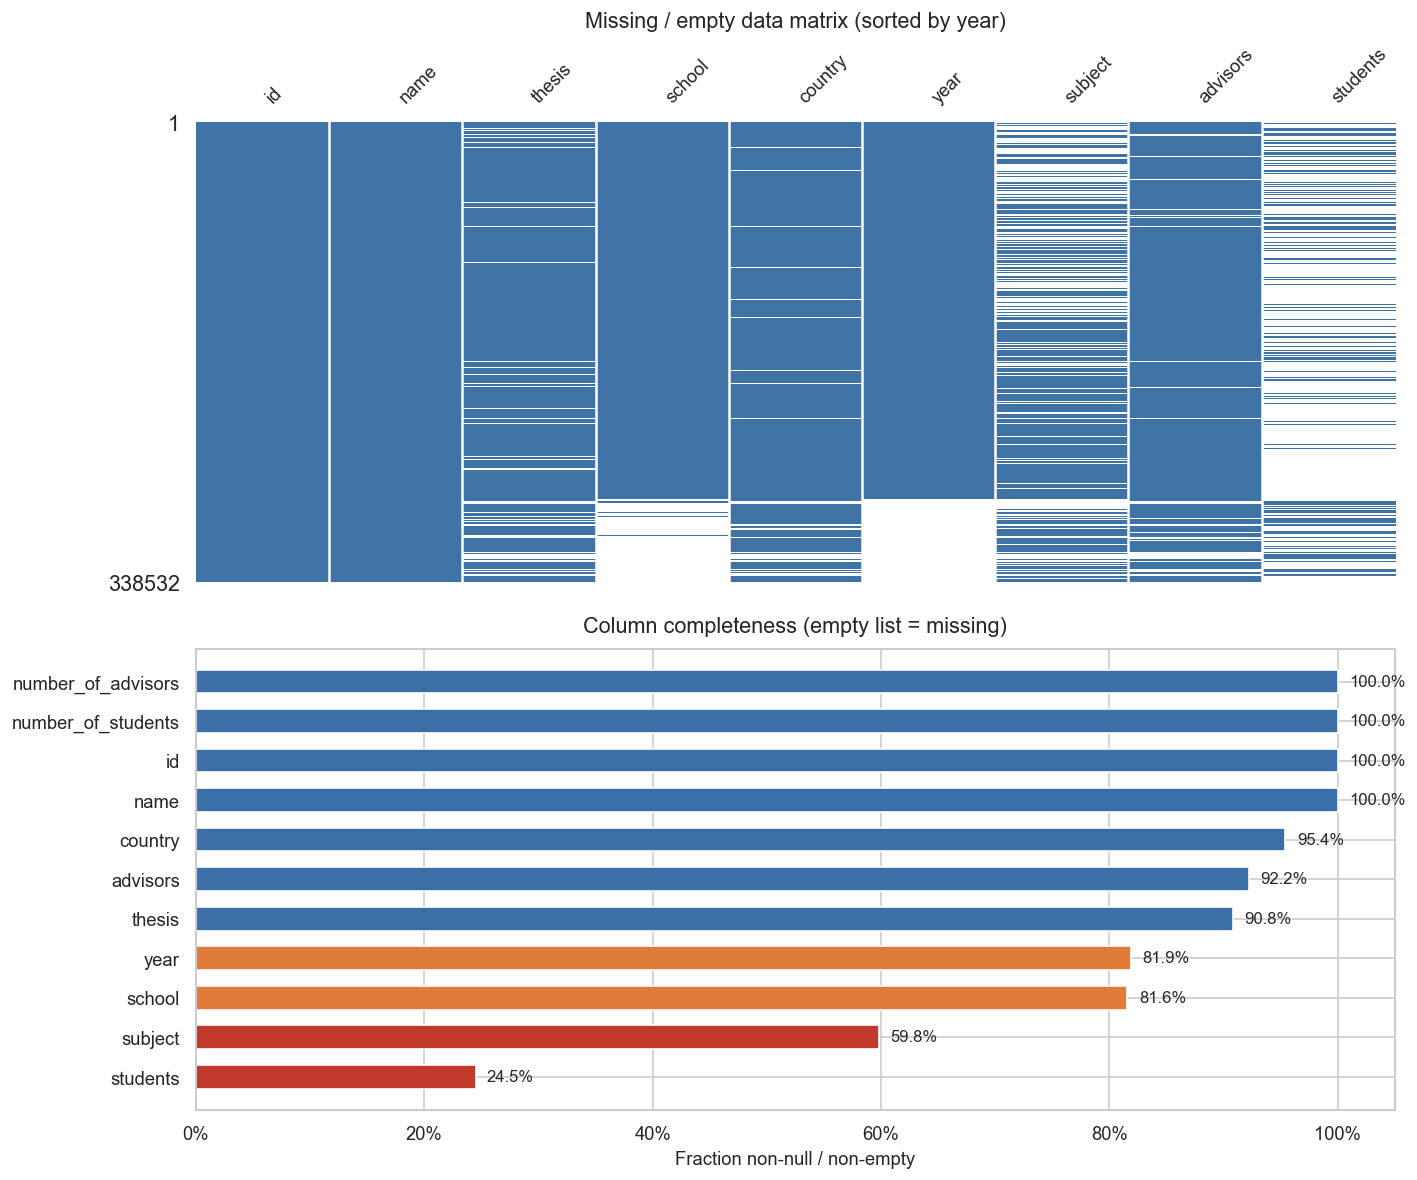

In [18]:
# --- completeness (treating empty lists as missing) ---

def is_present(val):
    """Returns False for None, NaN, empty string, and empty list."""
    if val is None:
        return False
    if isinstance(val, list):
        return len(val) > 0
    try:
        return pd.notna(val) and str(val).strip() != ""
    except Exception:
        return False

completeness = nodes.apply(lambda col: col.map(is_present).mean()).sort_values()

# --- missingno-style matrix (white = present, color = missing) ---
# build a boolean missing matrix for msno.matrix equivalent
import missingno as msno

col_order = ['id', 'name', 'thesis', 'school', 'country', 'year', 'subject', 'advisors', 'students']

# replace empty lists with NaN so msno sees them as missing
nodes_display = nodes[col_order].copy()
for col in ['advisors', 'students']:
    nodes_display[col] = nodes_display[col].apply(lambda x: None if isinstance(x, list) and len(x) == 0 else x)

nodes_sorted = nodes_display.sort_values(by='year')

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# left: missingno matrix
plt.sca(axes[0])
msno.matrix(
    nodes_sorted,
    ax=axes[0],
    sparkline=False,
    color=(0.25, 0.45, 0.65),
    fontsize=11,
)
axes[0].set_title("Missing / empty data matrix (sorted by year)", fontsize=13, pad=10)

# right: horizontal completeness bar chart
axes[1].barh(
    range(len(completeness)),
    completeness.values,
    color=[
        "#3a6fa8" if v >= 0.9 else "#e07b39" if v >= 0.6 else "#c0392b"
        for v in completeness.values
    ],
    edgecolor="white",
    height=0.6,
)
axes[1].set_yticks(range(len(completeness)))
axes[1].set_yticklabels(completeness.index, fontsize=11)
axes[1].set_xlabel("Fraction non-null / non-empty", fontsize=11)
axes[1].set_title("Column completeness (empty list = missing)", fontsize=13, pad=10)
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_xlim(0, 1.05)

# annotate with percentage
for i, v in enumerate(completeness.values):
    axes[1].text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("completeness_panel.png", dpi=150)
plt.show()

## 3. Student Count Distribution

The number of students per mathematician is extremely right-skewed: roughly 75% of
mathematicians have no listed students at all, and only a small fraction have more than
five. The distribution is shown on a log scale to make the tail visible.

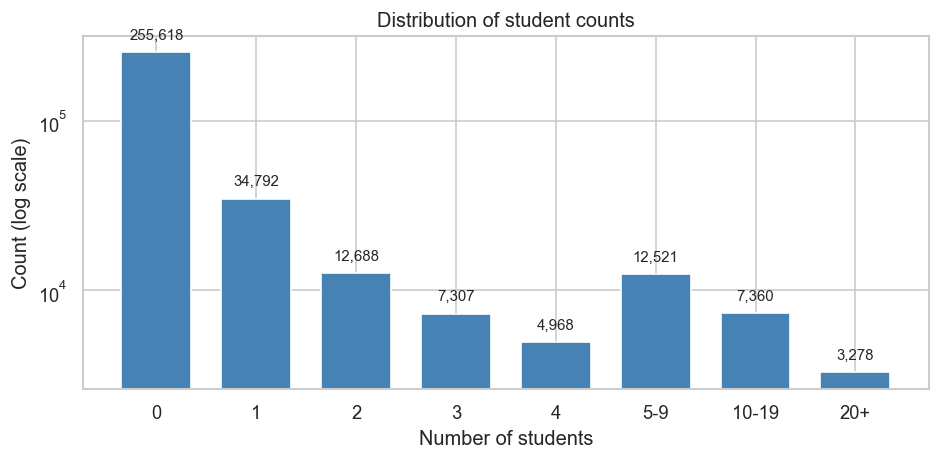

In [19]:
# custom bucketing: 0,1,2,3,4, then 5-9, 10-19, 20+
def bucket(n):
    if n <= 4:
        return str(n)
    elif n < 10:
        return "5-9"
    elif n < 20:
        return "10-19"
    else:
        return "20+"

bucket_order = ["0", "1", "2", "3", "4", "5-9", "10-19", "20+"]

nodes["student_bucket"] = nodes["number_of_students"].apply(bucket)
bucket_counts = nodes["student_bucket"].value_counts().reindex(bucket_order)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    bucket_order,
    bucket_counts.values,
    color="steelblue",
    edgecolor="white",
    width=0.7,
)
ax.set_yscale("log")
ax.set_xlabel("Number of students")
ax.set_ylabel("Count (log scale)")
ax.set_title("Distribution of student counts")

# annotate each bar with raw count
for i, v in enumerate(bucket_counts.values):
    ax.text(i, v * 1.15, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("student_count_dist.png", dpi=150)
plt.show()

## 4. PhD Output Over Time

### 4.1 All years (1700–2025)
The global histogram shows negligible activity before 1850, a slow rise through
the early 20th century, and an explosive growth phase from the 1950s onward driven
by the post-WWII academic expansion.

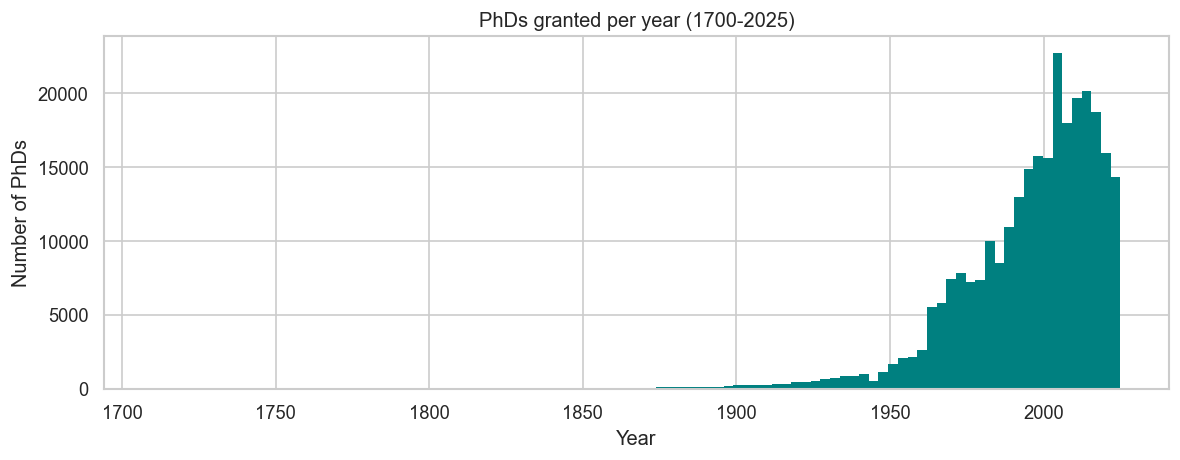

In [20]:
# filter out obvious outliers
year_clean = nodes["year"].dropna()
year_clean = year_clean[(year_clean >= 1700) & (year_clean <= 2025)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(year_clean, bins=100, color="teal", edgecolor="none")
ax.set_xlabel("Year")
ax.set_ylabel("Number of PhDs")
ax.set_title("PhDs granted per year (1700-2025)")
plt.tight_layout()
plt.savefig("phd_year_hist.png")
plt.show()

### 4.2 Modern period (1900–2025)
Zooming in to 1900 onward with 1-year bins reveals finer structure including the
post-Sputnik surge in the 1960s–70s and the apparent drop-off after ~2018, which
is a **data entry lag artifact** rather than a real decline — recent PhDs take
time to be entered into the MGP database.

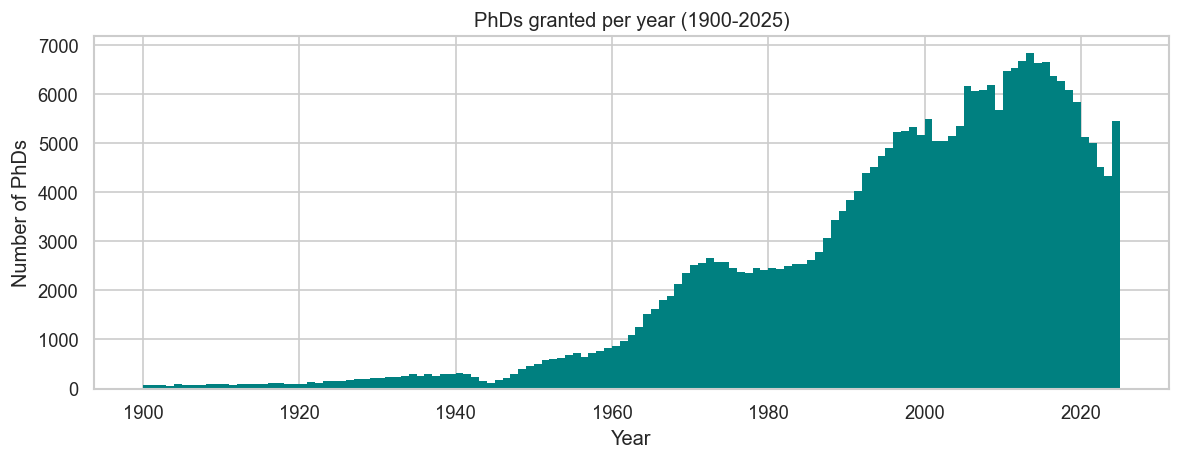

In [22]:
year_modern = year_clean[year_clean >= 1900]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(year_modern, bins=range(1900, 2026), color="teal", edgecolor="none")
ax.set_xlabel("Year")
ax.set_ylabel("Number of PhDs")
ax.set_title("PhDs granted per year (1900-2025)")
plt.tight_layout()
plt.show()

## 5. Geography


### 5.1 Top countries by record count
The United States dominates with 138,138 records — more than 3.5x the second-place
country. Germany ranks second with 38,430, followed by the Netherlands (24,055),
United Kingdom (18,269), and France (15,447). Beyond the top 5, counts drop sharply:
Canada has 9,193, Switzerland 8,096, and Russia 5,681.

The Netherlands ranking above the UK and France is surprising given its population size.
This reflects **MGP coverage depth rather than actual PhD output** — Dutch universities
have submitted records more systematically. This is confirmed by the school breakdown:
the Netherlands' 24,055 records come almost entirely from 15 identifiable institutions,
with Universiteit van Amsterdam alone accounting for 4,840. Germany's 38,430 records,
by contrast, are spread across hundreds of institutions with the largest (Göttingen)
contributing only 629 — suggesting many German records are simply not in the database.



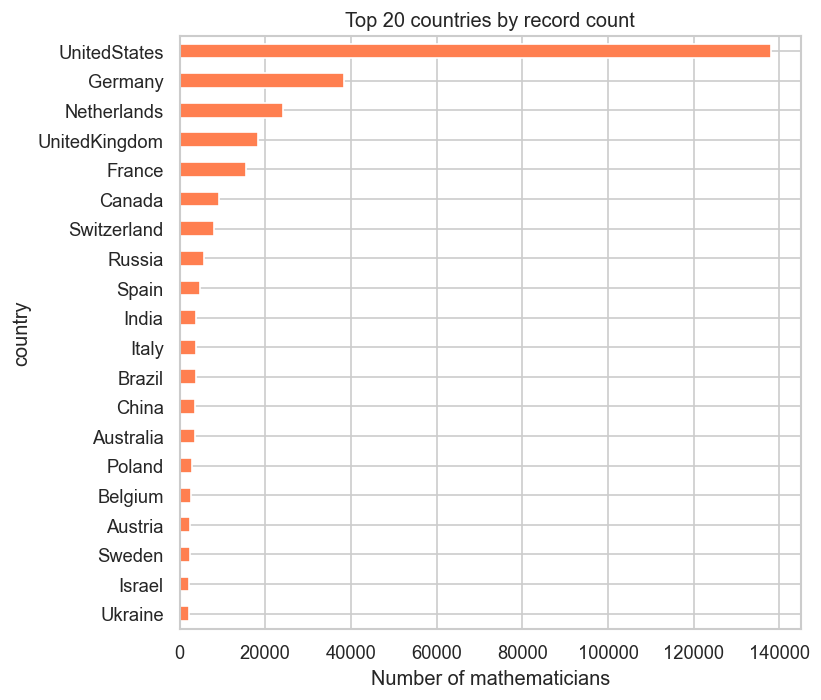

In [66]:
top_countries = (
    nodes["country"].dropna()
    .value_counts()
    .head(20)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(7, 6))
top_countries.plot.barh(ax=ax, color="coral")
ax.set_xlabel("Number of mathematicians")
ax.set_title("Top 20 countries by record count")
plt.tight_layout()
plt.savefig("top_countries.png")
plt.show()

In [68]:
print(nodes["country"].dropna().value_counts().head(10))
 

country
UnitedStates     138138
Germany           38430
Netherlands       24055
UnitedKingdom     18269
France            15447
Canada             9193
Switzerland        8096
Russia             5681
Spain              4758
India              3826
Name: count, dtype: int64



### 5.2 PhD output over time: top 5 countries
The US line rises steeply from the 1950s, peaking at roughly 3,200 PhDs per year
around 2005 before declining. The other four countries (Germany, Netherlands, UK,
France) each plateau in the 200–500 range and remain far below the US throughout.
All countries show a sharp drop after 2020, which is probably a **data entry lag artifact**
not a real decline.


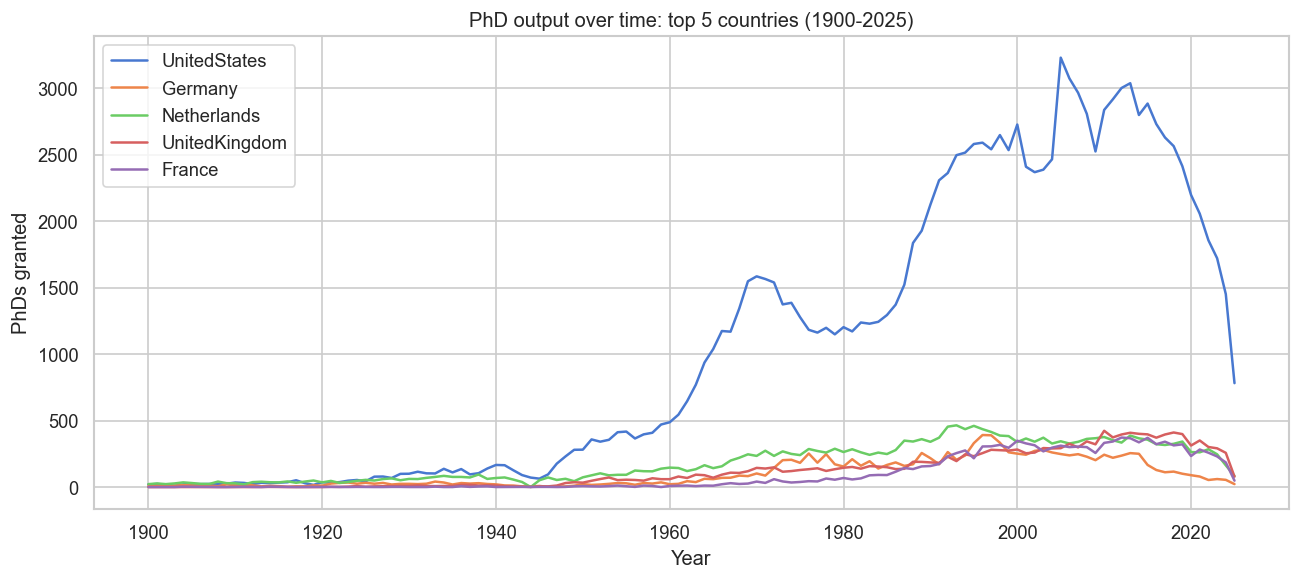

In [21]:
top5 = nodes["country"].value_counts().head(5).index.tolist()
subset = nodes[nodes["country"].isin(top5) & nodes["year"].notna()].copy()
subset = subset[(subset["year"] >= 1900) & (subset["year"] <= 2025)]

by_year_country = (
    subset.groupby(["year", "country"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(11, 5))
for country in top5:
    d = by_year_country[by_year_country["country"] == country]
    ax.plot(d["year"], d["count"], label=country, linewidth=1.5)

ax.set_xlabel("Year")
ax.set_ylabel("PhDs granted")
ax.set_title("PhD output over time: top 5 countries (1900-2025)")
ax.legend()
plt.tight_layout()
plt.savefig("phds_over_time_by_country.png")
plt.show()

### 5.3 Top countries per century
The century panels show a clear historical shift in where mathematics was institutionally
centered. The Netherlands leads in the 1501–1600 and 1601–1700 panels (though with
very small counts of 2 and 25 respectively). Germany takes over in 1701–1800 (12
records) and dominates 1801–1900 with 361 records, ahead of the Netherlands (334)
and a distant United States (210). By 1901–2000 the US has surged to 69,360 records
against the Netherlands' 14,797 and Germany's 8,076. The 2001–2100 panel (covering
only 2001–2025) shows the US still leading at 64,827, with UK (8,541), Netherlands
(8,284), and France (7,703) clustered closely behind.

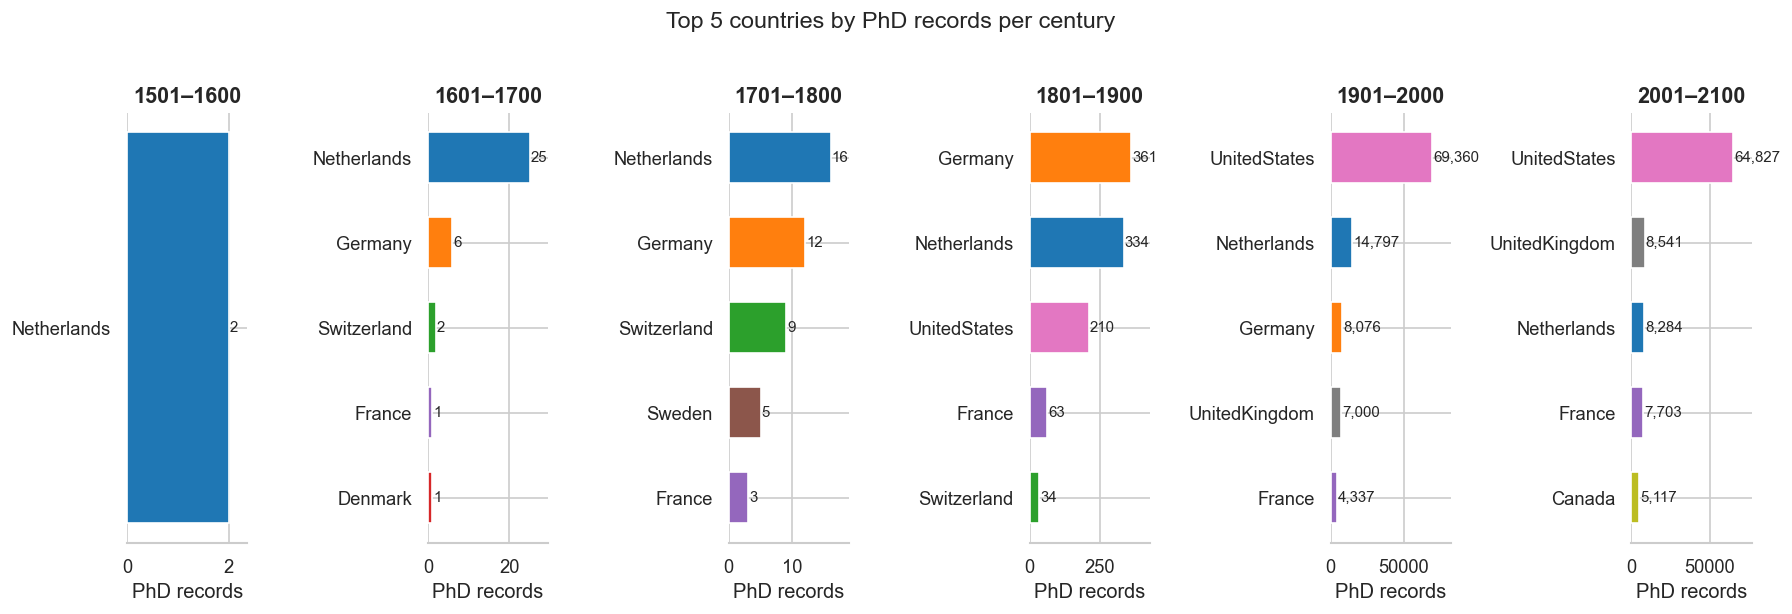

In [34]:
# bin years into centuries
def to_century(year):
    if pd.isna(year):
        return None
    c = int(year) // 100 + 1
    return f"{c*100 - 99}–{c*100}"  # e.g. "1901–2000"

nodes["century"] = nodes["year"].apply(to_century)

# only keep centuries with enough data and valid countries
valid = nodes[nodes["century"].notna() & nodes["country"].notna()].copy()

# count records per (century, country)
century_country = (
    valid.groupby(["century", "country"])
    .size()
    .reset_index(name="count")
)

# for each century, keep top 5 countries
top_per_century = (
    century_country
    .sort_values(["century", "count"], ascending=[True, False])
    .groupby("century")
    .head(5)
)

# only plot centuries with meaningful data (drop pre-1800 noise)
centuries_to_plot = ["1501–1600","1601–1700","1701–1800", "1801–1900", "1901–2000", "2001–2100"]
plot_data = top_per_century[top_per_century["century"].isin(centuries_to_plot)]

# assign a consistent color per country across panels
all_countries = plot_data["country"].unique()
palette = sns.color_palette("tab10", len(all_countries))
color_map = dict(zip(all_countries, palette))

fig, axes = plt.subplots(1, len(centuries_to_plot), figsize=(15, 5), sharey=False)

for ax, century in zip(axes, centuries_to_plot):
    data = (
        plot_data[plot_data["century"] == century]
        .sort_values("count")
    )
    bars = ax.barh(
        data["country"],
        data["count"],
        color=[color_map[c] for c in data["country"]],
        edgecolor="white",
        height=0.6,
    )
    # annotate
    for bar, val in zip(bars, data["count"]):
        ax.text(bar.get_width() + data["count"].max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=9)

    ax.set_title(century, fontsize=13, fontweight="bold")
    ax.set_xlabel("PhD records")
    ax.set_xlim(0, data["count"].max() * 1.18)
    sns.despine(ax=ax, left=True)
    ax.tick_params(left=False)

fig.suptitle("Top 5 countries by PhD records per century", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("countries_by_century.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Institutions

The top 20 schools are dominated by large US research universities, with MIT leading
at roughly 6,200 records, followed closely by UC Berkeley (~6,050) and Stanford
(~4,600). Harvard, Michigan, Wisconsin-Madison, Illinois, and UCLA all appear in the
4,000–3,800 range.

Four Dutch institutions appear in the top 20: Universiteit van Amsterdam (~4,840),
Rijksuniversiteit Groningen (~3,225), Technische Universiteit Delft (~3,114), and
Technische Universiteit Eindhoven (~2,965). Their presence this high reflects the
same systematic record submission from Dutch universities noted in Section 5 — it
does not mean these schools produced more math PhDs than, say, Oxford or Cambridge,
both of which appear lower in the ranking.

University of Cambridge is the only non-US, non-Dutch institution in the top 20,
reflecting the generally sparse MGP coverage of European universities outside the
Netherlands.

Note: one record with a blank school name (empty string rather than null) was
identified and excluded from this chart.

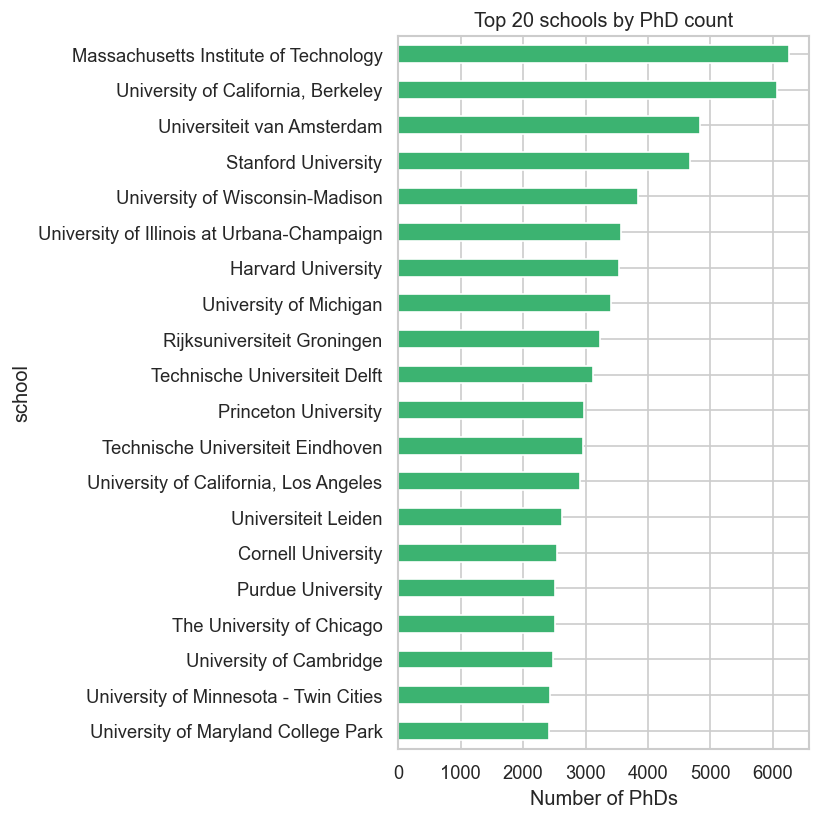

In [28]:
top_schools = (
    nodes["school"]
    .dropna()
    .replace("", pd.NA)   # catch empty strings
    .dropna()
    .str.strip()           # catch whitespace-only entries
    .replace("", pd.NA)
    .dropna()
    .value_counts()
    .head(20)
    .sort_values()
)
fig, ax = plt.subplots(figsize=(7, 7))
top_schools.plot.barh(ax=ax, color="mediumseagreen")
ax.set_xlabel("Number of PhDs")
ax.set_title("Top 20 schools by PhD count")
plt.tight_layout()
plt.savefig("top_schools.png")
plt.show()

## 7. Subject Areas (MSC Classification)


### 7.1 Top 20 MSC Subject Codes Overall

Computer science (68) is the single largest subject with ~35,000 records, nearly
double the second-place game theory and economics (91) at ~20,000, and statistics
(62) at ~18,000. After the top 3 there is a sharp drop: numerical analysis (65),
probability theory (60), and PDE (35) each sit around 7,000–8,000. The remaining
14 subjects in the top 20 are tightly clustered between 3,000 and 6,000 records,
including number theory (11), combinatorics (05), fluid mechanics (76), quantum
theory (81), and algebraic geometry (14).

Note that only 59.8% of records have a subject code, so these counts represent the
coded subset of 202,492 records rather than the full 338,526.

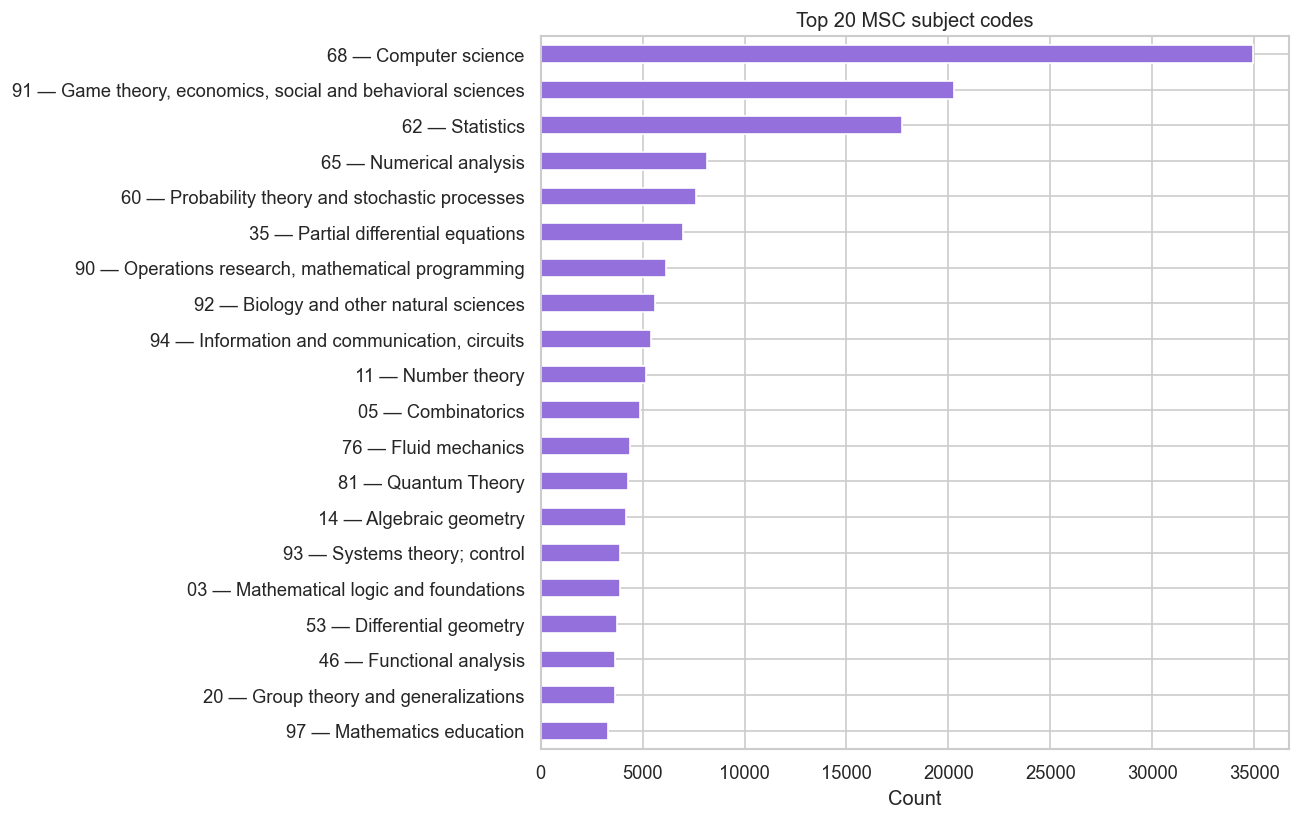

In [31]:
# split on the em dash (—)
nodes["subject_code"] = nodes["subject"].str.extract(r"^(\d{2})—")
nodes["subject_name"] = nodes["subject"].str.extract(r"^\d{2}—(.+)")

top_idx = nodes["subject_code"].value_counts().head(20).index

# most common name per code (should be identical, just a safety measure)
code_to_name = (
    nodes[nodes["subject_code"].isin(top_idx)]
    .dropna(subset=["subject_code", "subject_name"])
    .groupby("subject_code")["subject_name"]
    .agg(lambda x: x.mode()[0])
)

top_subjects = nodes["subject_code"].dropna().value_counts().head(20)
top_subjects.index = [
    f"{code} — {code_to_name.get(code, '?')}" for code in top_subjects.index
]
top_subjects = top_subjects.sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
top_subjects.plot.barh(ax=ax, color="mediumpurple")
ax.set_xlabel("Count")
ax.set_title("Top 20 MSC subject codes")
plt.tight_layout()
plt.savefig("top_subjects.png", dpi=150)
plt.show()

### 7.2 Dominant Subjects per Historical Period

The subject mix shifts substantially across periods, though early periods have very
sparse coverage and should be interpreted cautiously:

- **1700–1799 (n=15)**: Biology and natural sciences (92) leads with 6 records,
  followed by General (00) with 3. Counts are too small to draw conclusions.
- **1800–1849 (n=27)**: Astronomy and astrophysics (85) leads with 8 records.
  Still very sparse.
- **1850–1899 (n=231)**: Game theory and economics (91) appears at the top with
  39 records, followed by optics (78) with 31 and astronomy (85) with 24. The
  presence of 91 this early likely reflects historical economics dissertations
  being retroactively coded.
- **1900–1949 (n=2,382)**: Game theory and economics (91) dominates with 581
  records, followed by biology (92) at 176, optics (78) at 140, quantum theory
  (81) at 128, and astronomy (85) at 115. Pure math fields are largely absent,
  suggesting subject coding in this era skews toward applied and interdisciplinary work.
- **1950–1999 (n=51,110)**: The landscape modernizes sharply. Game theory (91)
  still leads at 8,896, but computer science (68) enters at 6,598 and statistics
  (62) at 4,143. Quantum theory (81) holds at 1,769 and probability (60) at 1,698.
- **2000–2025 (n=113,982)**: Computer science (68) takes the top spot decisively
  with 20,294 records, followed by statistics (62) at 11,820 and game theory (91)
  at 8,945. Numerical analysis (65) and probability (60) round out the top 5 at
  5,136 and 4,744 respectively.

Records per period:
period
Before 1700         2
1700–1799          15
1800–1849          27
1850–1899         231
1900–1949        2382
1950–1999       51110
2000–2025      113982
Name: count, dtype: int64


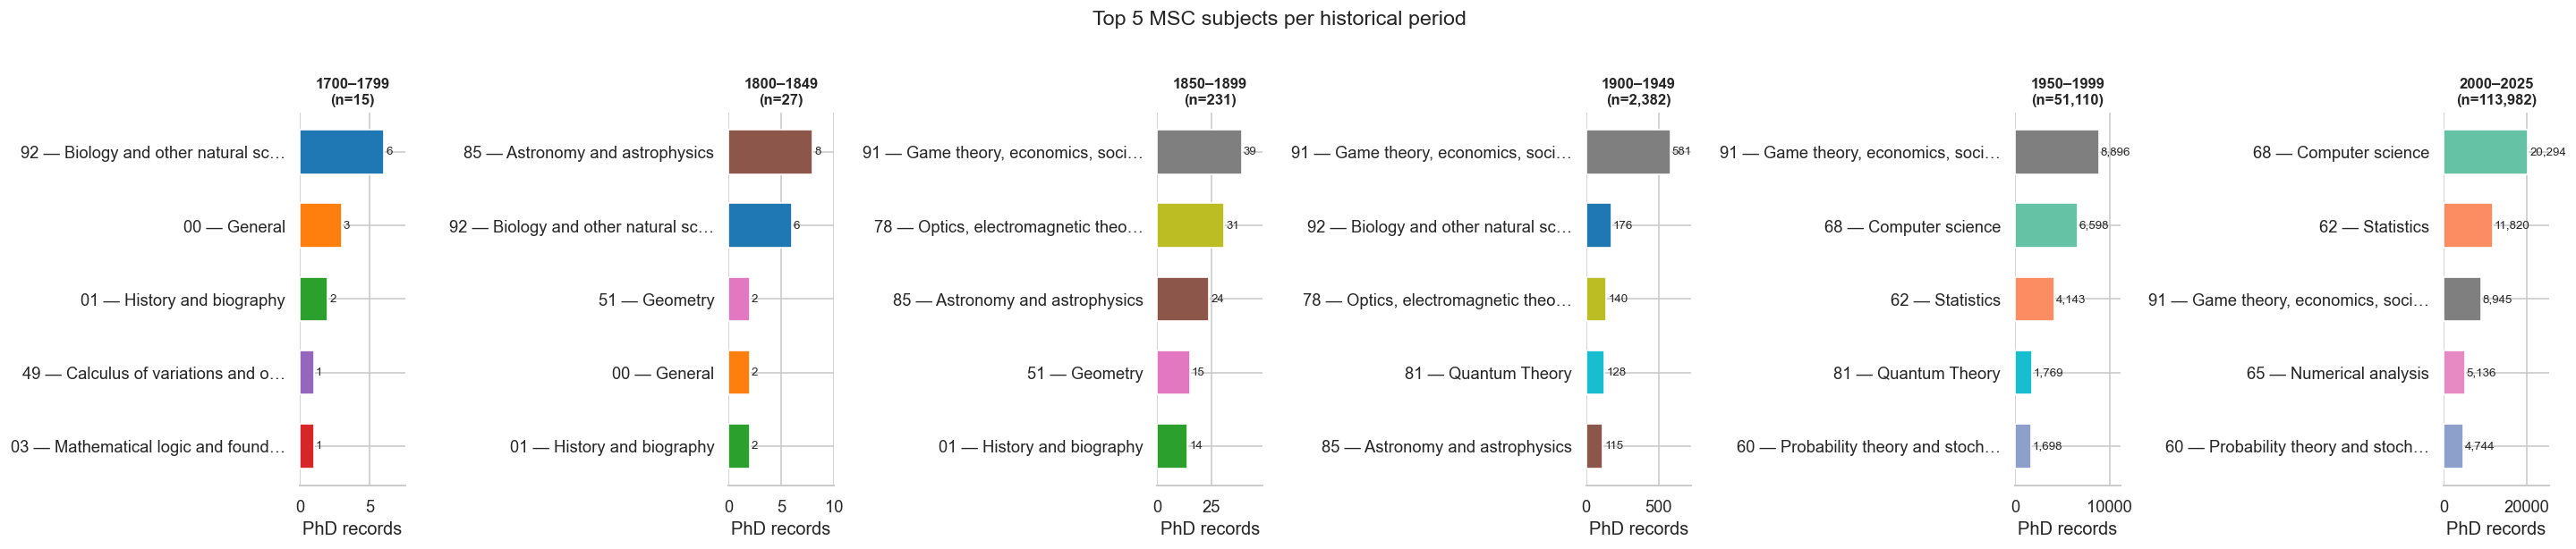

In [36]:
# bin years into meaningful historical periods
def to_period(year):
    if pd.isna(year):
        return None
    y = int(year)
    if y < 1700:
        return "Before 1700"
    elif y < 1800:
        return "1700–1799"
    elif y < 1850:
        return "1800–1849"
    elif y < 1900:
        return "1850–1899"
    elif y < 1950:
        return "1900–1949"
    elif y < 2000:
        return "1950–1999"
    else:
        return "2000–2025"

nodes["period"] = nodes["year"].apply(to_period)

# keep only rows with both period and subject
valid = nodes[nodes["period"].notna() & nodes["subject_code"].notna() & nodes["subject_name"].notna()].copy()

period_order = ["Before 1700", "1700–1799", "1800–1849", "1850–1899", "1900–1949", "1950–1999", "2000–2025"]

# count per (period, subject)
period_subject = (
    valid.groupby(["period", "subject_code", "subject_name"])
    .size()
    .reset_index(name="count")
)

# top 5 subjects per period
top_per_period = (
    period_subject
    .sort_values(["period", "count"], ascending=[True, False])
    .groupby("period")
    .head(5)
)

# drop periods with fewer than 10 total records (too sparse to be meaningful)
period_totals = valid["period"].value_counts()
valid_periods = period_totals[period_totals >= 10].index
top_per_period = top_per_period[top_per_period["period"].isin(valid_periods)]
periods_to_plot = [p for p in period_order if p in valid_periods]

print("Records per period:")
print(period_totals.reindex(period_order).dropna().astype(int))
n = len(periods_to_plot)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 5), sharey=False)

# consistent color per subject across panels
all_subjects = top_per_period["subject_code"].unique()
palette = sns.color_palette("tab10", min(len(all_subjects), 10))
extra = sns.color_palette("Set2", max(0, len(all_subjects) - 10))
color_map = dict(zip(all_subjects, palette + extra))

for ax, period in zip(axes, periods_to_plot):
    data = (
        top_per_period[top_per_period["period"] == period]
        .sort_values("count")
    )
    # label: "35 — Partial diff..."  truncated for space
    labels = [
        f"{row.subject_code} — {row.subject_name[:28]}{'…' if len(row.subject_name) > 28 else ''}"
        for row in data.itertuples()
    ]
    bars = ax.barh(
        labels,
        data["count"].values,
        color=[color_map[c] for c in data["subject_code"]],
        edgecolor="white",
        height=0.6,
    )
    for bar, val in zip(bars, data["count"].values):
        ax.text(
            bar.get_width() + data["count"].max() * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=8
        )
    total = period_totals[period]
    ax.set_title(f"{period}\n(n={total:,})", fontsize=10, fontweight="bold")
    ax.set_xlabel("PhD records")
    ax.set_xlim(0, data["count"].max() * 1.25)
    sns.despine(ax=ax, left=True)
    ax.tick_params(left=False)

fig.suptitle("Top 5 MSC subjects per historical period", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("subjects_by_period.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 Subject Trends Over Time (1900–2023)

The 5-year rolling average reveals three distinct phases:

**Pre-1960**: All subjects produce fewer than 50 PhDs per year. Game theory and
economics (91, orange) is the early leader, rising steadily from 1900 onward and
reaching ~175 by 1960. Everything else is essentially flat near zero.

**1960–1995**: CS (68, blue) begins its climb from near zero, crossing 100 around
1980 and accelerating through the 1990s. Statistics (62, green) and fluid mechanics
(76, orange-brown) also grow steadily. The remaining fields begin separating from
the baseline, with most reaching 50–100 PhDs per year by 1995.

**1995–2023**: CS surges to a peak of roughly 1,050 PhDs per year around 2008–2010
before declining sharply — partly a real trend as CS work moved into engineering
and interdisciplinary programs, and partly the data lag effect near 2023. Statistics
(62) peaks around 2020 at ~600. Game theory (91) peaks around 2018 at ~480. All
other subjects plateau in the 150–250 range. The sharp universal drop after 2020
is the same data entry lag artifact seen in the year histogram.

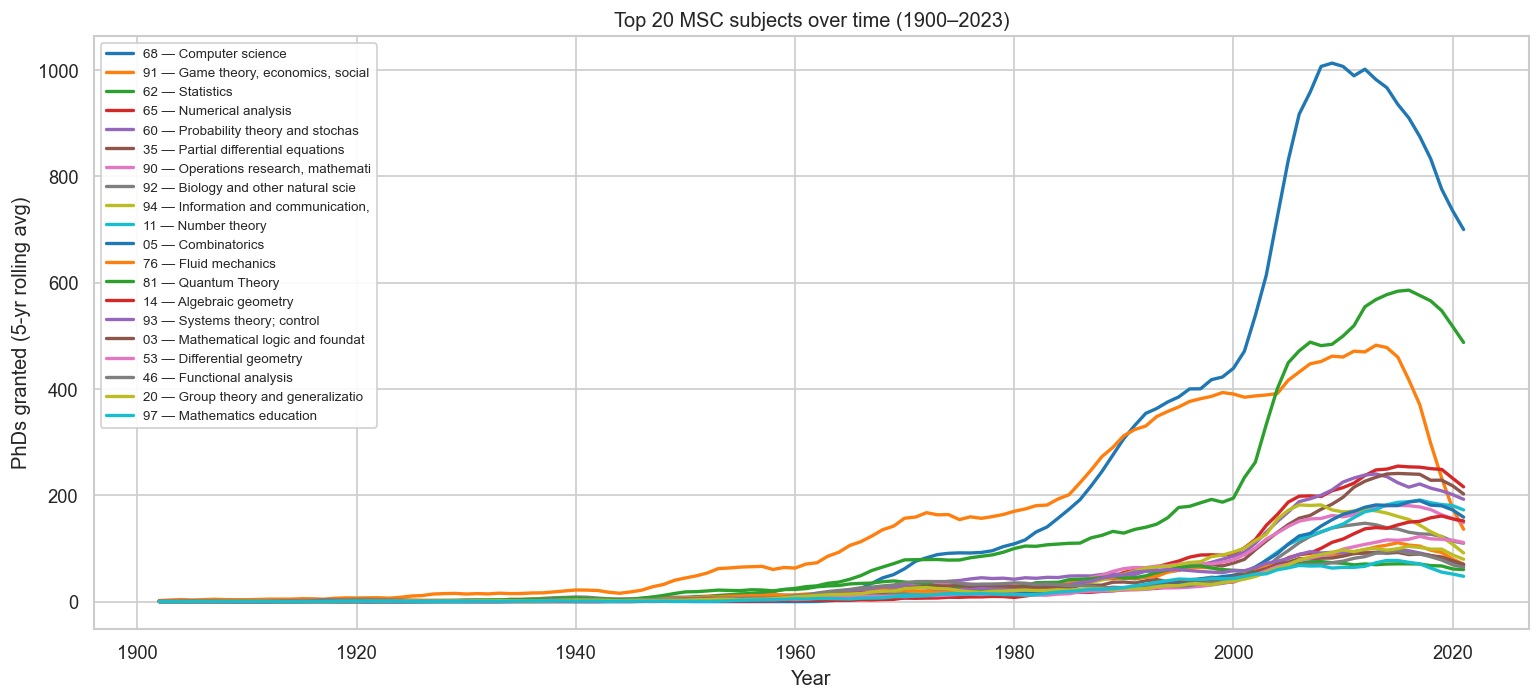

In [45]:
# pick top N subjects by total count to keep the plot readable
top_n = 20

top_subject_codes = (
    nodes["subject_code"].dropna()
    .value_counts()
    .head(top_n)
    .index.tolist()
)

# filter to valid rows
valid = nodes[
    nodes["subject_code"].isin(top_subject_codes) &
    nodes["year"].notna()
].copy()
valid = valid[(valid["year"] >= 1900) & (valid["year"] <= 2023)]

# build short readable labels
code_to_label = (
    valid.dropna(subset=["subject_code", "subject_name"])
    .groupby("subject_code")["subject_name"]
    .agg(lambda x: x.mode()[0])
    .str.slice(0, 30)  # truncate long names
)

by_year_subject = (
    valid.groupby(["year", "subject_code"])
    .size()
    .reset_index(name="count")
)

# 5-year rolling average per subject
fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette("tab10", top_n)

for i, code in enumerate(top_subject_codes):
    d = (
        by_year_subject[by_year_subject["subject_code"] == code]
        .set_index("year")["count"]
        .reindex(range(1900, 2024), fill_value=0)
        .rolling(5, center=True)
        .mean()
    )
    label = f"{code} — {code_to_label.get(code, '?')}"
    ax.plot(d.index, d.values, label=label, linewidth=2, color=palette[i])

ax.set_xlabel("Year")
ax.set_yscale("linear")
ax.set_xscale("linear")
ax.set_ylabel("PhDs granted (5-yr rolling avg)")
ax.set_title(f"Top {top_n} MSC subjects over time (1900–2023)")
ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig("subjects_over_time.png", dpi=150)
plt.show()

## 8. Subject Specialization by Country

We compute a lift score for each (country, subject) pair:

$$\text{lift} = \frac{\text{share of subject within country}}{\text{share of subject globally}}$$

A lift of 2.0x means a country produces twice the global proportion of PhDs in that
subject. Only subjects with at least 30 records per country are included to avoid
small-sample distortions. The dashed line marks lift = 1.0 (global average).

### Key findings by country

**United States (lift scores 1.22x–1.52x, modest specialization)**
The US shows the most uniform distribution of any country — no subject exceeds 1.52x.
Its strongest specializations are game theory and economics (91) at 1.52x, manifolds
and cell complexes (57) at 1.30x, and statistics (62) at 1.30x. The low lift scores
overall reflect the US producing PhDs broadly across all fields rather than
concentrating in any one tradition.

**Germany (lift scores 2.15x–2.99x)**
Germany's top specialization is history and biography of mathematics (01) at 2.99x,
followed by geometry (51) at 2.77x and real functions (26) at 2.37x. Mechanics of
particles (70) and field theory (12) also feature. This pattern is consistent with
Germany's classical 19th-century mathematical tradition in geometry and analysis,
and its strong historical scholarship.

**Netherlands (lift scores 2.31x–4.53x, physics-adjacent math)**
The Netherlands shows strong concentration in astronomy and astrophysics (85) at
4.53x and classical thermodynamics (80) at 4.35x, with statistical mechanics (82)
at 3.28x and quantum theory (81) at 2.67x. This is a clear physics-mathematics
interface signature, likely driven by the strong Dutch tradition in theoretical
physics (Lorentz, Ehrenfest, van der Waals) feeding into applied math PhDs.

**United Kingdom (lift scores 1.91x–3.61x, pure math and mathematical physics)**
The UK is most concentrated in group theory and generalizations (20) at 3.61x and
relativity and gravitational theory (83) at 3.60x — reflecting both a strong pure
algebra tradition and the British school of mathematical physics (Penrose, Hawking
and their descendants). Category theory (18) at 2.51x and measure and integration
(28) at 2.18x reinforce the pure mathematics orientation.

**France (lift scores 2.22x–2.88x, analysis and geometry)**
France's specializations read almost like a Bourbaki syllabus: PDE (35) at 2.88x,
several complex variables (32) at 2.87x, calculus of variations (49) at 2.63x,
global analysis on manifolds (58) at 2.58x, and field theory and polynomials (12)
at 2.42x. Probability theory (60) at 2.22x rounds out the list. This is one of the
most coherent national signatures in the dataset — a tightly defined tradition in
hard analysis and modern geometry.

**Canada (lift scores 1.59x–2.78x, discrete and algebraic math)**
Canada's top subject is combinatorics (05) at 2.78x, followed by linear and
multilinear algebra (15) at 2.07x and convex and discrete geometry (52) at 1.80x.
Operator theory (47) and category theory (18) also appear. This reflects a strong
Canadian school in discrete mathematics and algebraic structures, consistent with
the influence of institutions like Waterloo and Montreal.

**Switzerland (lift scores 1.43x–5.73x, natural sciences and geometry)**
Switzerland shows the widest spread of any country. Biology and natural sciences (92)
leads at 5.73x and geophysics (86) at 4.62x, suggesting many Swiss math PhDs sit at
the interface with natural sciences — consistent with the ETH Zurich tradition of
applied and interdisciplinary mathematics. Astronomy (85) at 2.51x follows, with
numerical analysis (65) and geometry (51) rounding out the list.

**Russia (lift scores 7.59x–12.62x, classical analysis)**
Russia has by far the strongest and most concentrated national signature in the
dataset. Ordinary differential equations (34) leads at 12.62x, followed by
functional analysis (46) at 10.31x, real functions (26) at 8.74x, general algebraic
systems (08) at 7.96x, functions of a complex variable (30) at 7.93x, and general
topology (54) at 7.59x. These lift scores are an order of magnitude higher than
most other countries. This is the direct fingerprint of the Soviet mathematical
school, which systematically prioritized classical hard analysis, topology, and
algebra from the 1930s through the 1980s.

### The CS exception
Computer science (68) does not appear in any country's top specializations. A direct
check confirms its lift is close to 1.0 across all eight countries. CS is a globally
distributed field with no geographic concentration, consistent with its emergence as
a universal applied discipline rather than one rooted in any particular national
mathematical tradition.

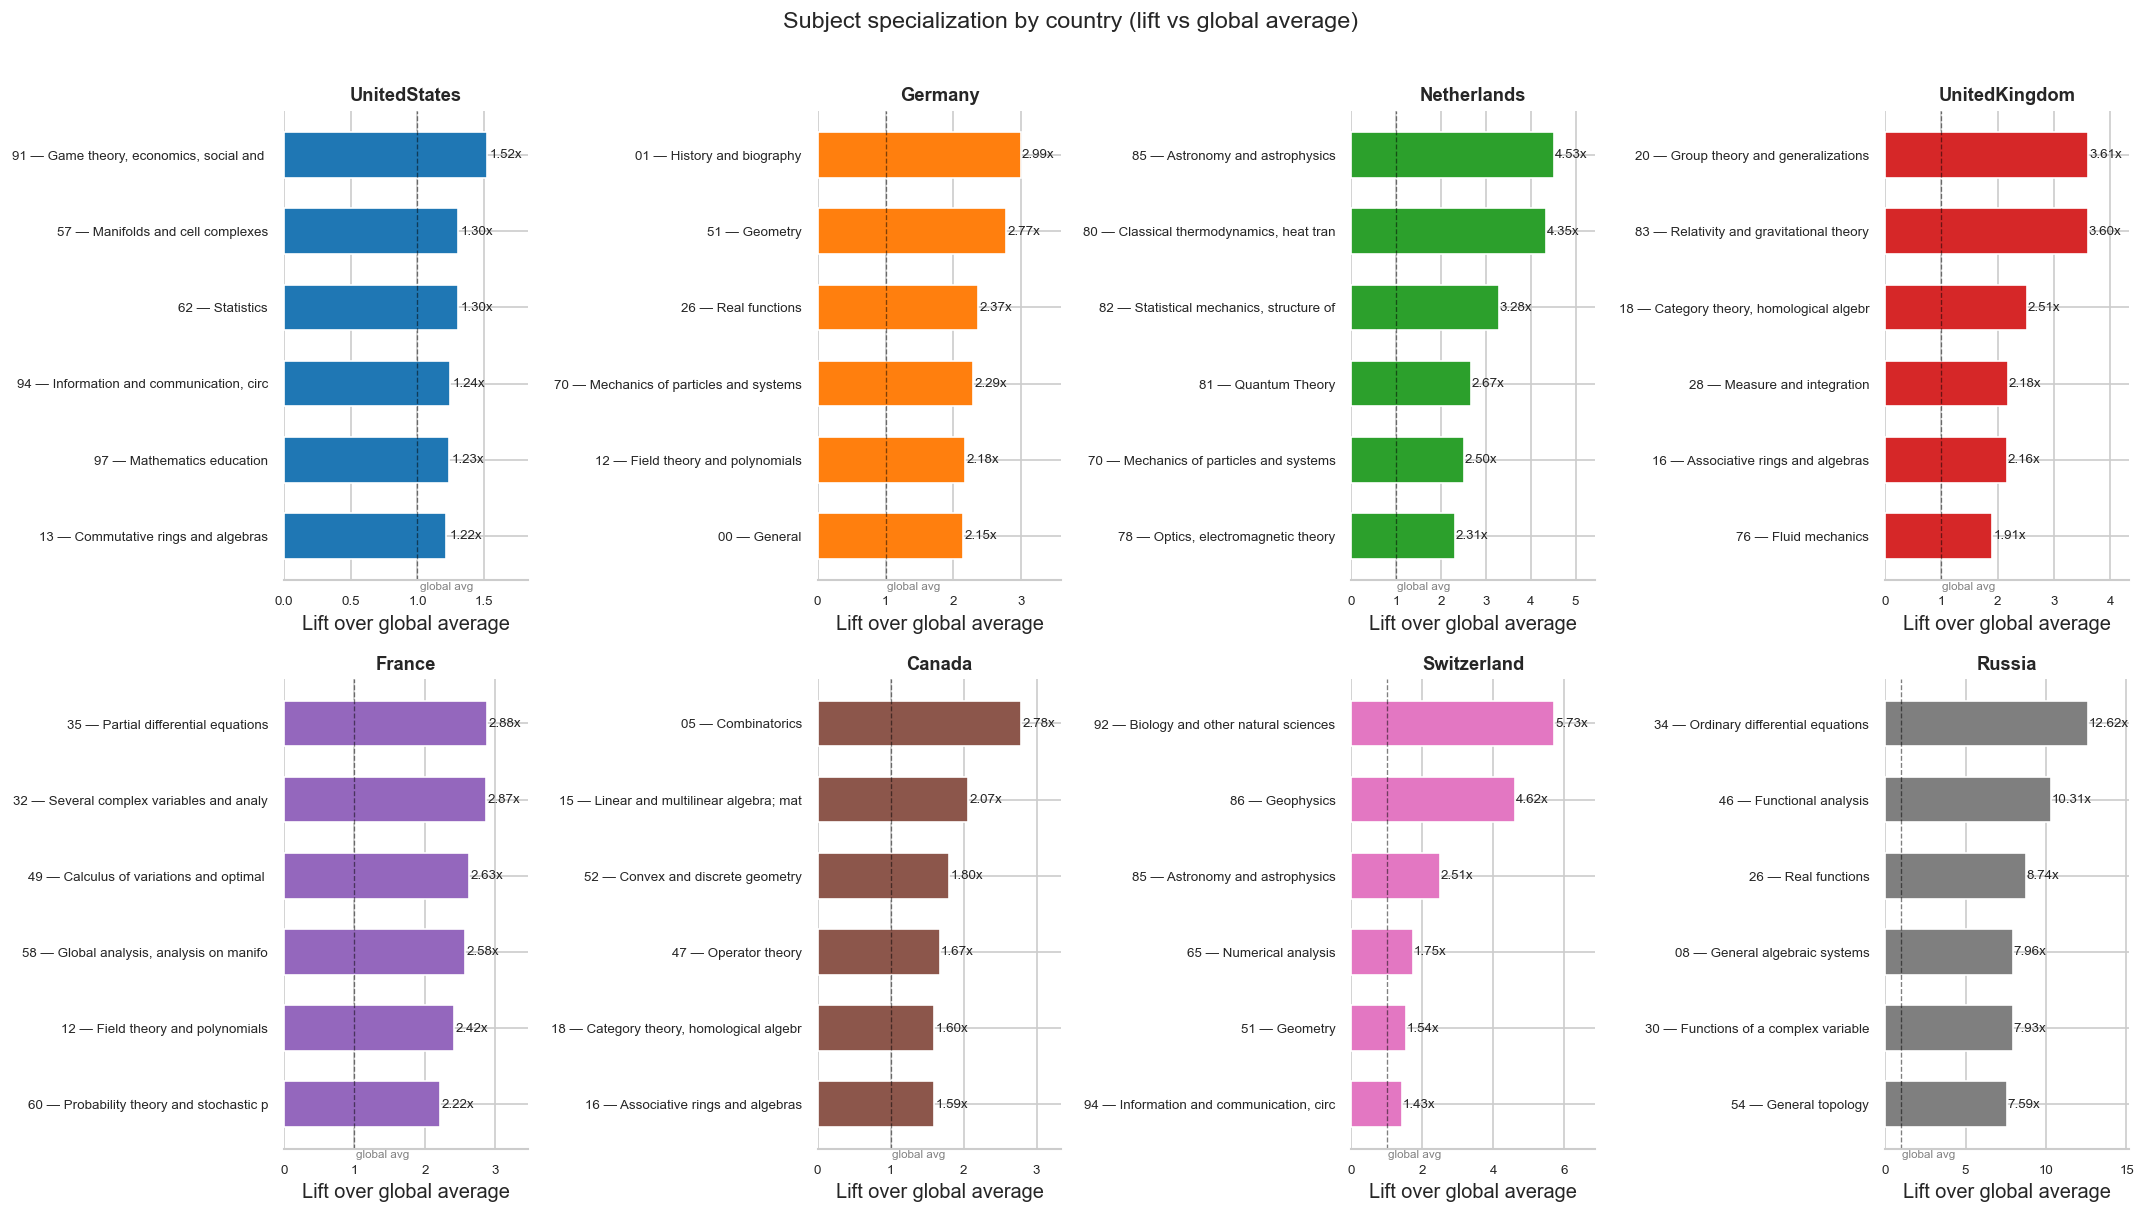

In [60]:
# lift = (share of subject within country) / (share of subject globally)
# lift > 1 means the country is overrepresented in that subject

top_countries = nodes["country"].value_counts().head(8).index.tolist()

valid = nodes[
    nodes["country"].isin(top_countries) &
    nodes["subject_code"].notna() &
    nodes["subject_name"].notna()
].copy()

# global subject shares
global_shares = valid["subject_code"].value_counts(normalize=True)

# compute lift per country x subject
records = []
for country in top_countries:
    country_data = valid[valid["country"] == country]
    country_shares = country_data["subject_code"].value_counts(normalize=True)
    for code, country_share in country_shares.items():
        global_share = global_shares.get(code, 0)
        if global_share > 0:
            lift = country_share / global_share
            name = (
                valid[valid["subject_code"] == code]["subject_name"]
                .mode()[0][:35]
            )
            records.append({
                "country": country,
                "subject_code": code,
                "subject_name": name,
                "lift": lift,
                "count": country_data["subject_code"].eq(code).sum(),
            })

lift_df = pd.DataFrame(records)

# for each country keep top 6 by lift, but require at least 30 records
# to avoid obscure subjects inflating lift on tiny counts
top_lift = (
    lift_df[lift_df["count"] >= 30]
    .sort_values("lift", ascending=False)
    .groupby("country")
    .head(6)
)

# plot
n_countries = len(top_countries)
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharey=False)
axes = axes.flatten()

country_palette = sns.color_palette("tab10", n_countries)

for i, country in enumerate(top_countries):
    ax = axes[i]
    data = (
        top_lift[top_lift["country"] == country]
        .sort_values("lift")
    )
    label = [
        f"{row.subject_code} — {row.subject_name}"
        for row in data.itertuples()
    ]
    bars = ax.barh(
        label,
        data["lift"].values,
        color=country_palette[i],
        edgecolor="white",
        height=0.6,
    )
    # reference line at lift=1 (global average)
    ax.axvline(1, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.text(1.02, -0.7, "global avg", fontsize=7, color="gray")

    for bar, val in zip(bars, data["lift"].values):
        ax.text(
            bar.get_width() + 0.02,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}x",
            va="center", fontsize=8,
        )

    ax.set_title(country, fontsize=11, fontweight="bold")
    ax.set_xlabel("Lift over global average")
    ax.set_xlim(0, data["lift"].max() * 1.2)
    sns.despine(ax=ax, left=True)
    ax.tick_params(left=False, labelsize=8)

fig.suptitle("Subject specialization by country (lift vs global average)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("subject_lift_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

In [61]:
cs_lift = lift_df[lift_df["subject_code"] == "68"][["country", "lift", "count"]].sort_values("lift", ascending=False)
print(cs_lift.to_string(index=False))

      country     lift  count
      Germany 1.456321   6465
       Canada 1.243933   1319
       France 1.158148   2586
  Netherlands 1.137046   1088
  Switzerland 0.965213    724
 UnitedStates 0.914909  14179
UnitedKingdom 0.715801   1770
       Russia 0.149749    127


## 9. Thesis Title Analysis

In [49]:
nodes["thesis"].dropna().head(10).tolist()

['Statics of Special Types of Homogeneous Elastic Slabs with Variable Thickness',
 'The Approximate Solution of Linear Differential Equations by the Use of Functionals',
 'Statical Equilibrium of Skew and Sector-Shaped Plates',
 'Stresses in Moderately Thick Rectangular Plates',
 'Finite Strain Analysis in Elastic Theory',
 'Solutions of Clamped Plated Problems by Means of Functions Derived from Membrane Characteristic Functions',
 'Explicit Solutions of Certain Singular Integral Equations',
 'Flow of Viscous Fluid between Slowing Rotating, Eccentric Cylinders',
 'Properties of Kernels of Integral Equations Whose Iterates Satisfy Linear Relations',
 'Analytical Study of Dynamic Loads on Elastically Supported Slabs']

### 9.1 Global Word Cloud

The global word cloud across all 307,399 thesis titles with recorded titles reveals
the dominant vocabulary of mathematical research. The largest words — "System",
"Dynamic", "Model", "Analysis", "Structure" — reflect the broad applied orientation
of the dataset, which skews heavily toward post-1950 PhDs when applied fields
overtook classical pure mathematics in volume.

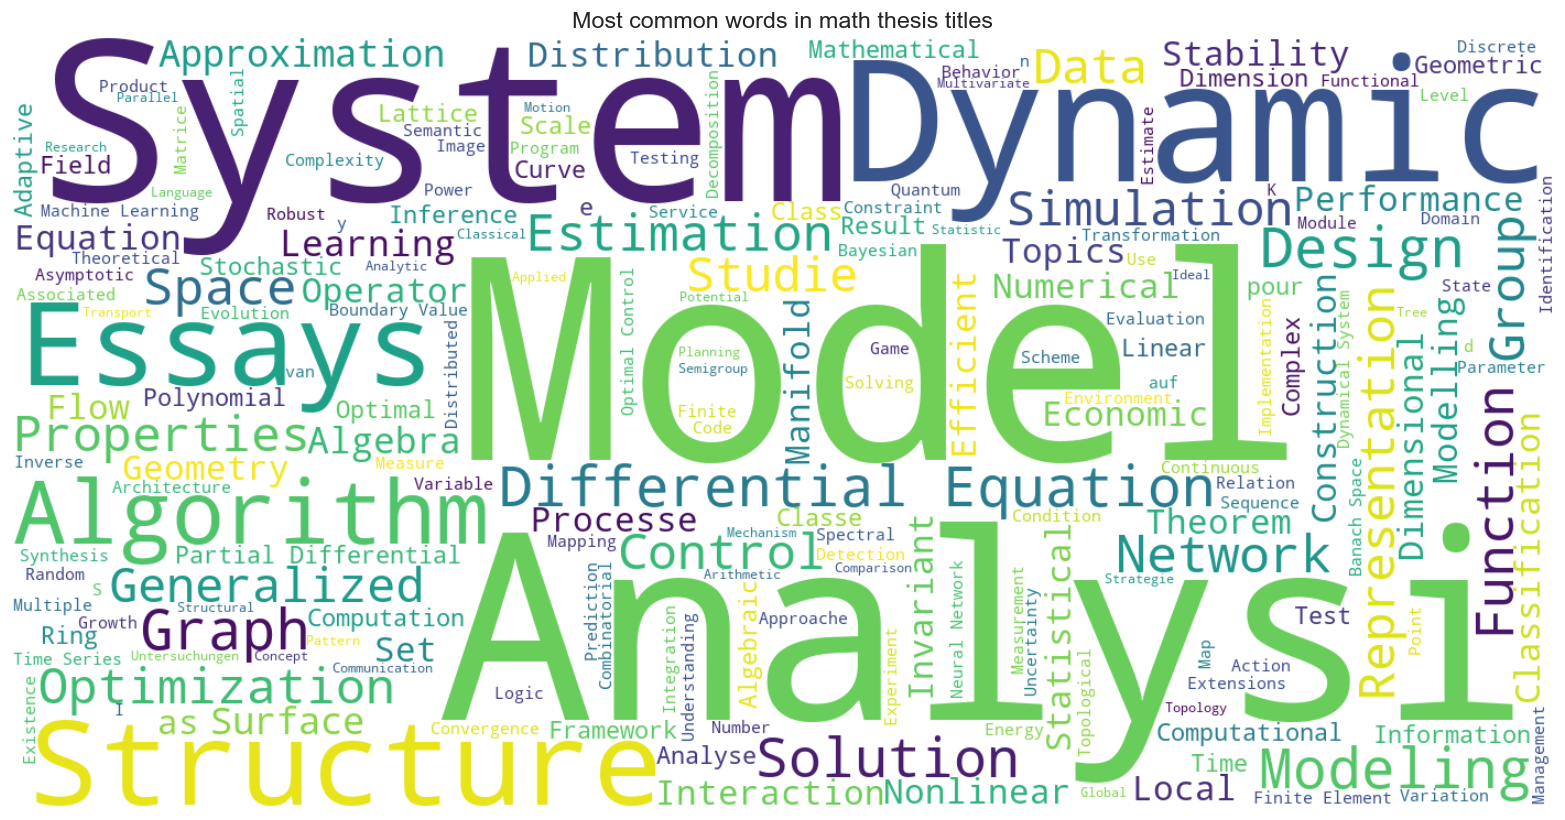

In [55]:
from wordcloud import WordCloud

text = " ".join(nodes["thesis"].dropna().tolist())

wc = WordCloud(
    width=1400, height=700,
    background_color="white",
    colormap="viridis",
    stopwords={# generic english
    "the", "a", "an", "of", "in", "and", "for", "on", "with", "to", "by",
    "from", "at", "is", "its", "their", "some", "using", "based", "via",
    "under", "through", "non", "two", "three", "multi", "large", "high",
    "new", "real", "general", "various", "certain", "related", "over",
    "between", "within", "about", "toward", "towards", "case", "cases",
    "role", "type", "types", "effect", "effects", "impact", "aspect",
    "aspects", "topic", "essay", "study", "thesis", "problem", "problems",
    # french
    "de", "la", "le", "les", "sur", "du", "des", "en", "et", "une", "un",
    "par", "au", "aux", "dans", "avec", "à",
    # german
    "und", "der", "die", "das", "ein", "eine", "über", "uber", "zur",
    "zum", "bei", "im", "zu", "mit", "von", "für", "fur", "als",
    # structural filler
    "approach", "method", "methods", "technique", "techniques",
    "contribution", "contributions", "introduction", "investigation",
    "development", "extension", "generalization", "characterization",
    "application", "applications", "theory","theorie", "theories",},
    max_words=200,
).generate(text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Most common words in math thesis titles", fontsize=14)
plt.tight_layout()
plt.savefig("thesis_wordcloud.png", dpi=150)
plt.show()

### 9.2 Word Clouds by Top 3 MSC Subjects

Three iterations of the subject-level word clouds were produced, progressively
removing cross-domain and generic academic vocabulary to surface the most
field-distinctive terminology. The final version (Image 4) with the most aggressive
stopword filtering gives the clearest signal.

**68 — Computer Science**
The final cloud is dominated by "Algorithm", "Software", "Language", "Machine",
"Graph", "Distributed", "Optimization", and "Processing". The presence of "Machine"
and "Language" reflects the growth of machine learning and natural language
processing as dominant subfields within CS PhDs. "Distributed", "Parallel", and
"Wireless" point to systems and networking research. "Verification" and "Security"
appear as smaller but consistent themes.

**91 — Game Theory, Economics, Social and Behavioral Sciences**
The economics cloud centers on "Economic", "Market", "Labor", "Financial",
"International", "Policy", and "Growth". "Macroeconomic", "Equilibrium", "Trade",
and "Political" are prominent in the mid-tier. This vocabulary is clearly
distinguishable from the other two fields, with almost no overlap in the top terms —
confirming that thesis language alone carries strong signal for this MSC code.

**62 — Statistics**
The statistics cloud shows "Regression", "Bayesian", "Statistical", "Multivariate",
"Nonparametric", "Longitudinal", "Survival", and "Likelihood" as the dominant terms.
"Dimensional", "Stochastic", "Linear", and "Variable" are also prominent. The
presence of "Clinical", "Disease", "Gene", and "Survival" reflects the heavy
overlap between statistics PhDs and biostatistics applications.

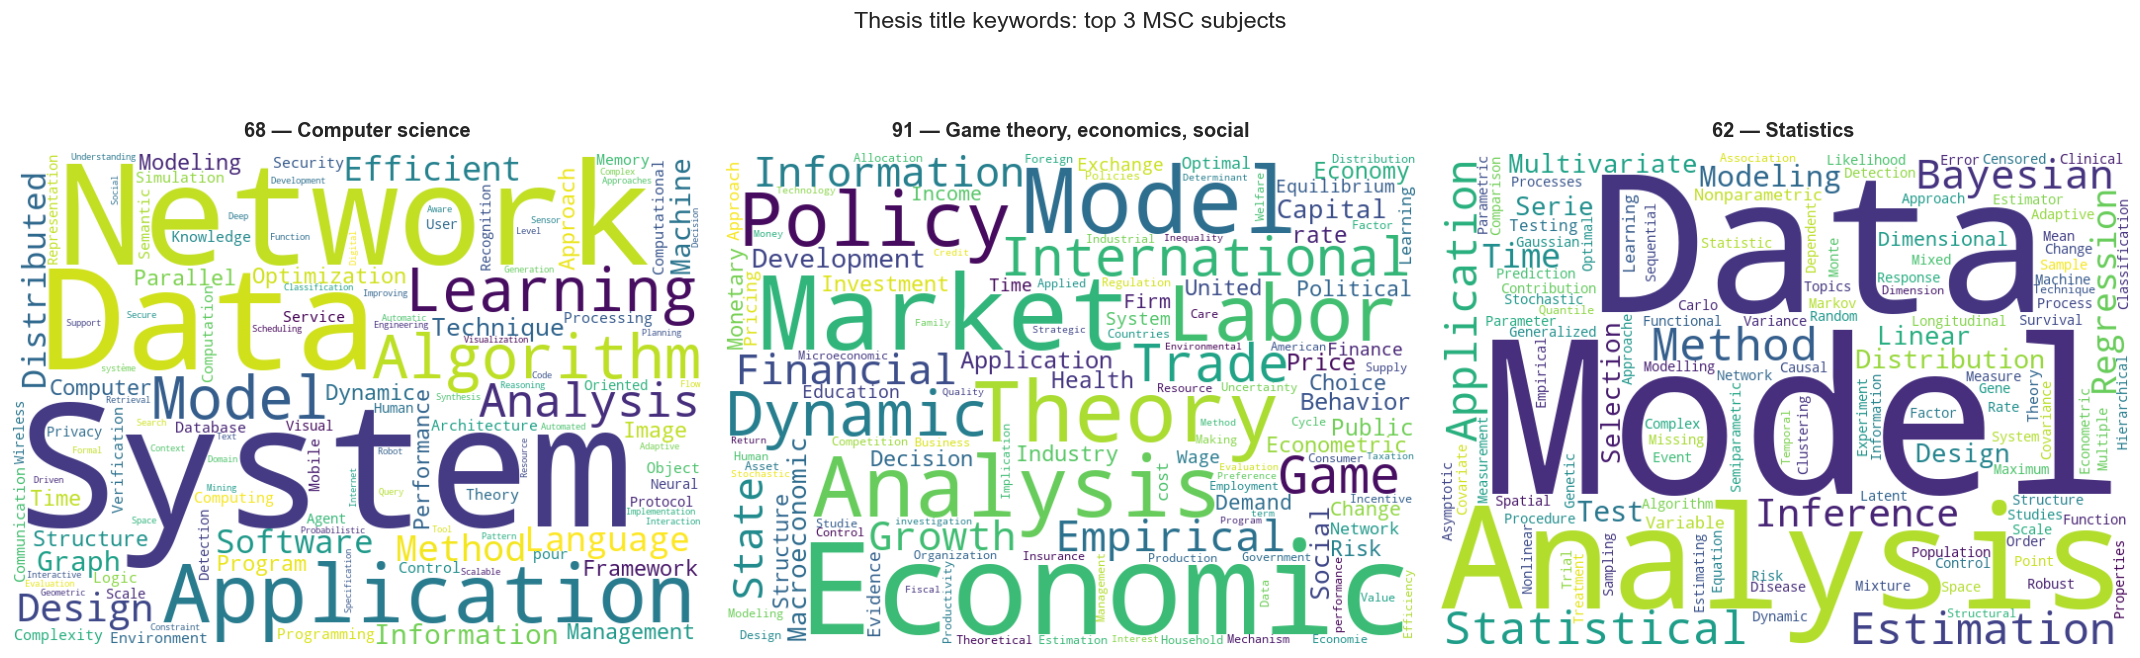

In [59]:
from wordcloud import WordCloud

custom_stopwords = {
    # generic english
    "the", "a", "an", "of", "in", "and", "for", "on", "with", "to", "by",
    "from", "at", "is", "its", "their", "some", "using", "based", "via",
    "under", "through", "non", "two", "three", "multi", "large", "high",
    "new", "real", "general", "various", "certain", "related", "over",
    "between", "within", "about", "toward", "towards", "case", "cases",
    "role", "type", "types", "effect", "effects", "impact", "aspect",
    "aspects", "topic", "essay","essays", "study", "thesis", "problem", "problems",
    # french
    "de", "la", "le", "les", "sur", "du", "des", "en", "et", "une", "un",
    "par", "au", "aux", "dans", "avec", "à",
    # german
    "und", "der", "die", "das", "ein", "eine", "über", "uber", "zur",
    "zum", "bei", "im", "zu", "mit", "von", "für", "fur", "als",
}

top3_codes = (
    nodes["subject_code"].dropna()
    .value_counts()
    .head(3)
    .index.tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, code in zip(axes, top3_codes):
    mask = nodes["subject_code"] == code
    text = " ".join(nodes.loc[mask, "thesis"].dropna().tolist())
    name = code_to_label.get(code, code)

    wc = WordCloud(
        width=700, height=500,
        background_color="white",
        colormap="viridis",
        stopwords=custom_stopwords,
        max_words=120,
        collocations=False,   # avoids repeating bigrams
        min_word_length=4,    # cuts "van", "Two", "Non" etc.
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{code} — {name}", fontsize=12, fontweight="bold", pad=10)

fig.suptitle("Thesis title keywords: top 3 MSC subjects", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("thesis_wordcloud_top3.png", dpi=150, bbox_inches="tight")
plt.show()

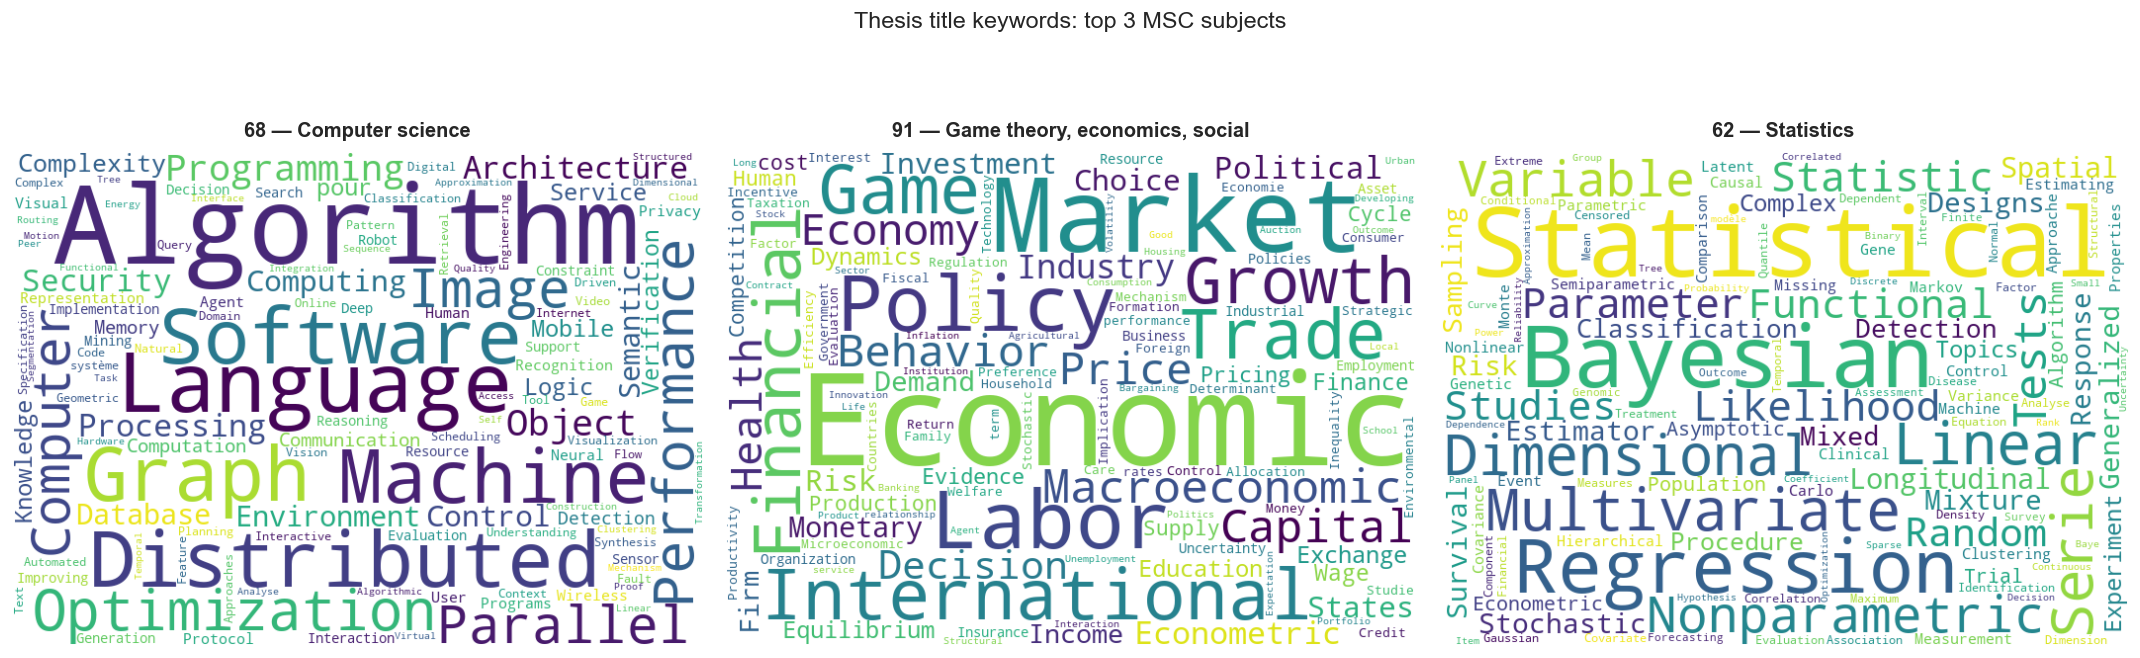

In [70]:
from wordcloud import WordCloud

custom_stopwords = {
    # generic english
    "the", "a", "an", "of", "in", "and", "for", "on", "with", "to", "by",
    "from", "at", "is", "its", "their", "some", "using", "based", "via",
    "under", "through", "non", "two", "three", "multi", "large", "high",
    "new", "real", "general", "various", "certain", "related", "over",
    "between", "within", "about", "toward", "towards", "case", "cases",
    "role", "type", "types", "effect", "effects", "impact", "aspect",
    "aspects", "topic", "essay","essays", "study", "thesis", "problem", "problems",
    # french
    "de", "la", "le", "les", "sur", "du", "des", "en", "et", "une", "un",
    "par", "au", "aux", "dans", "avec", "à",
    # german
    "und", "der", "die", "das", "ein", "eine", "über", "uber", "zur",
    "zum", "bei", "im", "zu", "mit", "von", "für", "fur", "als",
    # structural filler
    "approach", "method", "methods", "technique", "techniques",
    "contribution", "contributions", "introduction", "investigation",
    "development", "extension", "generalization", "characterization",
    "application", "applications", "theory"," theory","theorie", "theories",
}
extra_stopwords = {
    # generic academic
    "applied", "theoretical", "formal", "empirical", "optimal",
    "numerical", "computational", "probabilistic", "sequential",
    "adaptive", "oriented", "automatic", "scalable", "efficient",
    "robust", "secure", "aware", "making", "based",
    # vague nouns
    "structure", "structures", "system", "systems", "process", "processes",
    "framework", "frameworks", "design", "model", "models", "analysis",
    "information", "management", "program", "function", "functions",
    "state", "space", "level", "scale", "rate", "time", "change",
    "value", "values", "order", "point", "error", "measure",
    # cross-domain (appear in all 3, not distinctive)
    "data", "network", "networks", "dynamic", "learning",
    "modeling", "modelling", "estimation", "inference",
    "distribution", "distributions", "simulation", "prediction",
    # leftover short filler
    "united", "american", "public", "social", "corporate",
    "multiple", "testing", "test", "sample", "selection",
}

custom_stopwords = custom_stopwords | extra_stopwords
top3_codes = (
    nodes["subject_code"].dropna()
    .value_counts()
    .head(3)
    .index.tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, code in zip(axes, top3_codes):
    mask = nodes["subject_code"] == code
    text = " ".join(nodes.loc[mask, "thesis"].dropna().tolist())
    name = code_to_label.get(code, code)

    wc = WordCloud(
        width=700, height=500,
        background_color="white",
        colormap="viridis",
        stopwords=custom_stopwords,
        max_words=120,
        collocations=False,   # avoids repeating bigrams
        min_word_length=4,    # cuts "van", "Two", "Non" etc.
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{code} — {name}", fontsize=12, fontweight="bold", pad=10)

fig.suptitle("Thesis title keywords: top 3 MSC subjects", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("thesis_wordcloud_top3.png", dpi=150, bbox_inches="tight")
plt.show()

### 9.4 Thesis Title Keywords: Top 10 MSC Subjects

Expanding the word cloud analysis to the top 10 MSC subjects confirms that
thesis title vocabulary is strongly field-specific across all ten codes, not
just the top three.

The top row covers the five largest fields. CS (68) centers on "System",
"Network", "Algorithm", and "Data". Economics (91) is anchored by "Economic",
"Market", "Labor", and "International". Statistics (62) shows "Model", "Data",
"Statistical", and "Bayesian". Numerical analysis (65) is immediately
recognizable from "Numerical", "Equation", "Finite", and "Method" — the
language of discretization and solvers. Probability theory (60) separates
cleanly with "Stochastic", "Markov", "Random", "Diffusion", and "Brownian",
terms that rarely appear in the other four panels.

The bottom row covers more specialized fields. PDE (35) is dominated by
"Equation", "Elliptic", "Nonlinear", "Boundary", "Parabolic", and "Solution"
— classical PDE vocabulary with almost no overlap with CS or economics.
Operations research (90) shows "Optimization", "Scheduling", "Programming",
"Routing", and "Integer", reflecting its algorithmic and logistics focus.
Biology and natural sciences (92) stands out with "Cell", "Protein",
"Biological", "Cancer", "Genetic", and "Population" — the most domain-specific
vocabulary in the entire grid and the clearest evidence that MSC 92 captures
math biology and bioinformatics PhDs rather than pure mathematics. Information
and communication (94) is defined by "Signal", "Channel", "Network",
"Wireless", and "Communication", reflecting coding theory and telecommunications.
Number theory (11) closes the grid with the most distinctively pure math
vocabulary: "Arithmetic", "Modular", "Diophantine", "Galois", "Automorphic",
"Conjecture", and "Form" — terms that would be nearly invisible in any of the
other nine panels.

Taken together, the ten clouds suggest that even a simple bag-of-words
representation of thesis titles carries substantial discriminative signal for
MSC classification across fields ranging from pure mathematics to applied
biology.

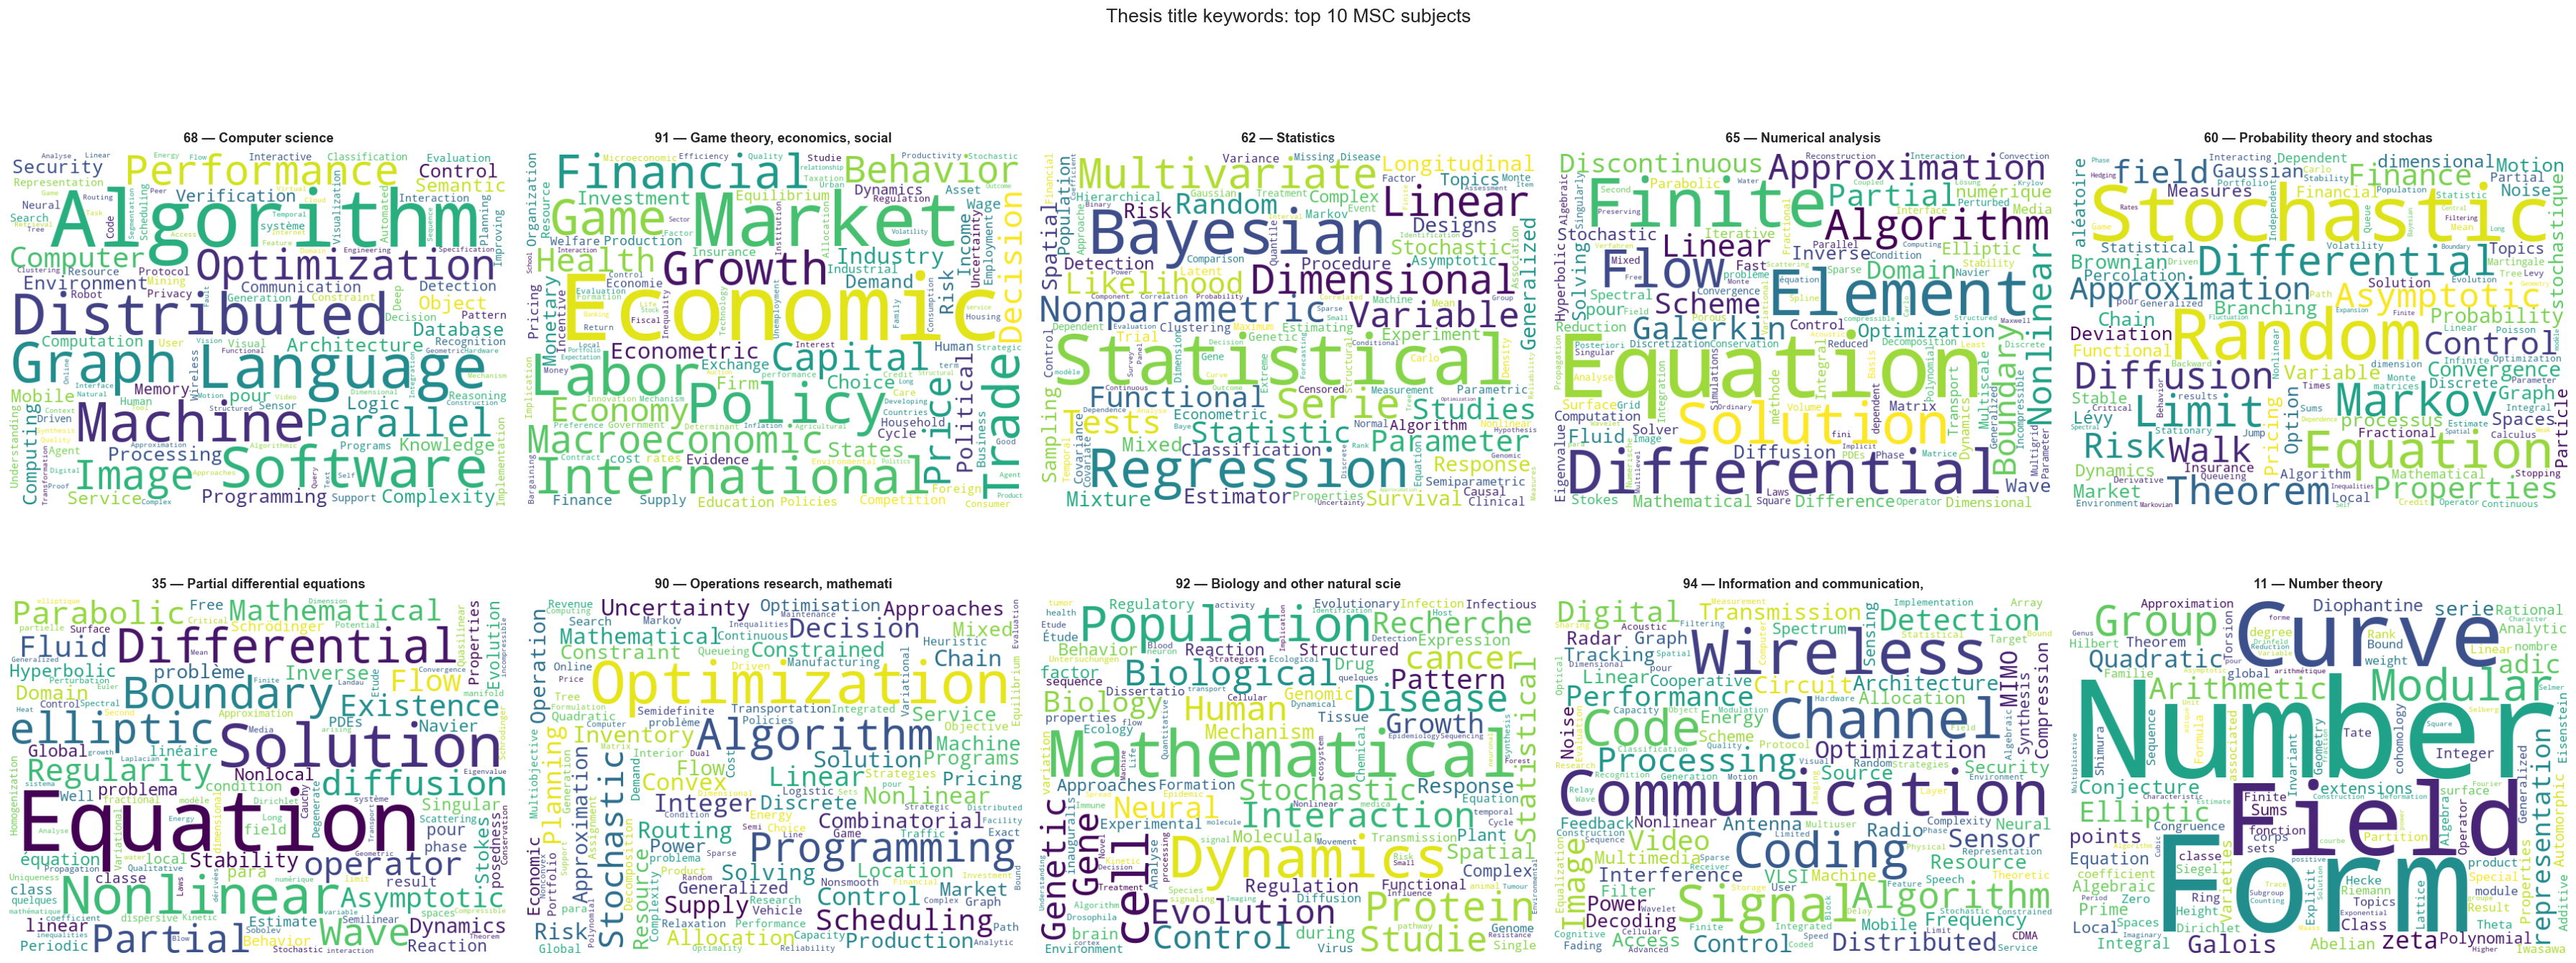

In [72]:
top10_codes = (
    nodes["subject_code"].dropna()
    .value_counts()
    .head(10)
    .index.tolist()
)

fig, axes = plt.subplots(2, 5, figsize=(30, 12))
axes = axes.flatten()

for ax, code in zip(axes, top10_codes):
    mask = nodes["subject_code"] == code
    text = " ".join(nodes.loc[mask, "thesis"].dropna().tolist())
    name = code_to_label.get(code, code)

    wc = WordCloud(
        width=700, height=500,
        background_color="white",
        colormap="viridis",
        stopwords=custom_stopwords,
        max_words=120,
        collocations=False,
        min_word_length=4,
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{code} — {name}", fontsize=11, fontweight="bold", pad=8)

fig.suptitle("Thesis title keywords: top 10 MSC subjects", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("thesis_wordcloud_top10.png", dpi=150, bbox_inches="tight")
plt.show()